##### Copyright 2024 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Data Scientist Assistant using LangChain Agents

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/langcahin/LangChain Agent as a Data Scientist.ipynb"><img src = "https://www.tensorflow.org/images/colab_logo_32px.png"/>Run in Google Colab</a>
  </td>
</table>

In this notebook, you will learn how to pair Gemini with LangChain's agent for DataFrames.

This will enable the creation of a Data Scientist Assistant capable of analyzing data, identifying relationships, drawing conclusions, and developing models for predictions.

LangChain is a framework designed to simplify the creation of applications that utilize large language models, thanks to its versatile components and integrations.


[Agents](https://api.python.langchain.com/en/latest/experimental_api_reference.html) are one of these components. They use LLMs as a reasoning engine to dynamically decide which actions to take.

### Set-up

Install and import needed libraries.

In [ ]:
!pip install -U -q langchain-google-genai langchain_experimental

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 3.5 MB/s eta 0:00:00


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

### Configure your API key

To run the following cell, your API key must be stored in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb) for an example.


In [ ]:
import os
from google.colab import userdata
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

## Load the data


This demo will utilize the "Predict Students' Dropout and Academic Success" dataset from the UCI ML repository.

This dataset from a higher education institution includes student enrollment details, demographics, socio-economic factors, and academic performance, used to create classification models predicting dropout and academic success, with a notable class imbalance.

For more info go to: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

In [ ]:
# install UCI ML repository package
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

#download the dataset
dataset = fetch_ucirepo(id=697)
data = dataset.data.original

In [ ]:
data.head(5)

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Create an Agent


As a first step, initialize Gemini with the temperature set to 0.0. This ensures that the model issues precise and consistent commands to the various libraries it can access.

This means that by setting the temperature to 0.0, you're minimizing variability and ensuring that the model behaves predictably when interacting with other tools.

In [ ]:
llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash-latest", temperature=0.0)

To create the assistant, utilize the ready-to-use function create_pandas_dataframe_agent from the [langachain-experimental package](https://api.python.langchain.com/en/latest/experimental_api_reference.html). The LLM will be Gemini initialized in the previous step.

*NOTE:This agent relies on access to a python repl tool which can execute arbitrary code. This can be dangerous and requires a specially sandboxed environment to be safely used. Please read the security notice in the doc-string of this function. You must opt-in to use this functionality by setting allow_dangerous_code=True. For general security guidelines, please see: https://python.langchain.com/v0.2/docs/security/*

In [ ]:
df_agent = create_pandas_dataframe_agent(
    llm,
    data,
    verbose=True,
    allow_dangerous_code=True,
    include_df_in_prompt=True,
    number_of_head_rows=10
)

## Use the Agent

Start by prompting the Agent for a short summary of the data.

In [ ]:
df_agent.invoke("Examine this data and provide a description of approximately 100 words.")



> Entering new AgentExecutor chain...
Thought: I need to understand the data to provide a description. I can use the `describe()` method to get summary statistics.
Action: python_repl_ast
Action Input: print(df.describe())       Marital Status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance  Previous qualification  \
count                 4424.000000      

{'input': 'Examine this data and provide a description of approximately 100 words.',
 'output': 'The dataset contains information on 4424 student enrollments, with 37 variables including demographic information, academic history, financial status, and academic performance. The data is primarily numerical, with a few categorical variables. The dataset appears to be focused on understanding factors that influence student success and dropout rates.'}

The agent provided a descriptive output. To verify it, let's check the summary of the data using the info() method.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

You can see that the agent's description is correct.

Now, ask the Agent for some insights on data relations.

In [ ]:
df_agent.invoke("Do you think it is possible to predict who will graduate or dropout?")



> Entering new AgentExecutor chain...
Thought: I need to see if there are any relationships between the features and the target variable.
Action: python_repl_ast
Action Input: print(df.groupby('Target').mean())          Marital Status  Application mode  Application order       Course  \
Target                                                                       
Dropout         1.261084         23.712878           1.593244  8755.629838   
Enrolled        1.152393         19.799748           1.625945  8868.811083   
Graduate        1.134903         15.018108           1.851064  8917.248076   

          Daytime/evening attendance  Previous qualification  \
Target                                                         
Dropout                     0.854328                5.311049   
Enrolled                    0.905542                4.785894   
Graduate                    0.909009                4.031236   

          Previous qualification (grade)  Nacionality  Mother's qualificatio

{'input': 'Do you think it is possible to predict who will graduate or dropout?',
 'output': 'Yes, it is possible to predict who will graduate or dropout based on the features in the dataset. The differences in the average values of the features between the different target groups suggest that there might be a relationship between the features and the target variable.'}

Check if the Agent is capable of producing accurate charts.



> Entering new AgentExecutor chain...
Thought: I need to create a cross tabulation of the two columns and then plot it.
Action: python_repl_ast
Action Input: print(pd.crosstab(df['Scholarship holder'], df['Daytime/evening attendance']))NameError: name 'pd' is not definedThought: I need to import pandas first.
Action: python_repl_ast
Action Input: import pandas as pdAction: python_repl_ast
Action Input: print(pd.crosstab(df['Scholarship holder'], df['Daytime/evening attendance']))Daytime/evening attendance    0     1
Scholarship holder                   
0                           419  2906
1                            64  1035
Thought: I need to create a bar chart to visualize the relationship.
Action: python_repl_ast
Action Input: pd.crosstab(df['Scholarship holder'], df['Daytime/evening attendance']).plot(kind='bar')Axes(0.125,0.11;0.775x0.77)Thought: I now know the final answer. The chart is created.
Final Answer: The chart is created.

> Finished chain.


{'input': 'Can you create a chart for relation between Scholarship holder and Daytime/evening attendance??',
 'output': 'The chart is created.'}

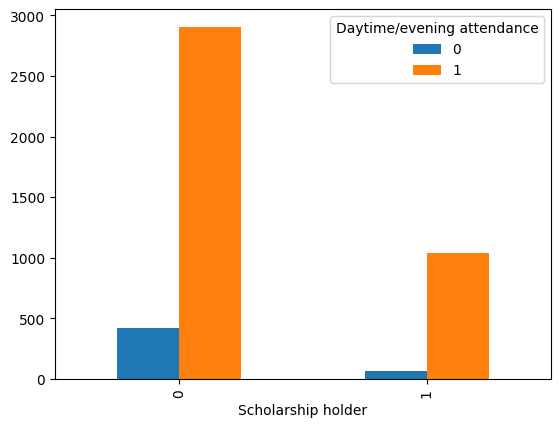

In [ ]:
df_agent.invoke("Can you create a chart for relation between Scholarship holder and Daytime/evening attendance??")

Request the Agent to perform a more complex task: training multiple models on the data and comparing their performance.


The Agent should start by splitting the data into training and test sets, then train the models, generate predictions from each, and compare their scores.

In [ ]:
df_agent.invoke("Train some models to predict which student will graduate and which will dropout and select the best model.")



> Entering new AgentExecutor chain...
Thought: I need to import the necessary libraries and split the data into features and target.
Action: python_repl_ast
Action Input: import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_scoreThought: I need to split the data into features and target.
Action: python_repl_ast
Action Input: X = df.drop('Target', axis=1)
y = df['Target']Thought: I need to split the data into training and testing sets.
Action: python_repl_ast
Action Input: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)Thought: I need to train the models and evaluate their performance.
Action: python_repl_ast
Action Input: models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tr

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Thought: The error message indicates that the `precision_score`, `recall_score`, and `f1_score` functions are expecting a binary classification problem, but the target variable has multiple classes. I need to adjust the `average` parameter to handle multiclass classification.
Action: python_repl_ast
Action Input: models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', pos_label='Graduate')
    recall = recall_score(y_test, y_pred, average='weighted', pos_label='Graduate')
    f1 = f1_score(y_test, y_pred, average='weighted', pos_label='Graduate')
    print(f'{model_name}:')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'Graduate') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1523: UserWarning: Note that pos_label (set to 'Graduate') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label

Logistic Regression:
Accuracy: 0.6588
Precision: 0.6173
Recall: 0.6588
F1-score: 0.6028
---
Decision Tree:
Accuracy: 0.6746
Precision: 0.6822
Recall: 0.6746
F1-score: 0.6768
---
Random Forest:
Accuracy: 0.7672
Precision: 0.7563
Recall: 0.7672
F1-score: 0.7532
---
Thought: Based on the evaluation metrics, the Random Forest model performs the best with the highest accuracy, precision, recall, and F1-score.
Final Answer: The Random Forest model is the best model for predicting student graduation status. 


> Finished chain.


{'input': 'Train some models to predict which student will graduate and which will dropout and select the best model.',
 'output': 'The Random Forest model is the best model for predicting student graduation status.'}

You can observe that the Agent executed the following steps without explicit prompts:

1. Imported necessary libraries,
2. Split the data into training and test sets,
3. A dictionary of models was created (Logistic Regression, Decision Tree and Random Forest). Each model was trained on the training set and evaluated on the test set, with performance metrics including accuracy, precision, recall, and F1-score calculated.
4. Based on the evaluation metrics, the agent determined that the Random Forest model performed the best for predicting student graduation status.

## Summary
You've acquired the knowledge to integrate Gemini with LangChain's pre-built components for conducting data analysis and machine learning tasks. Now, you can implement your ideas or import another dataset to explore further.

## What's next?

This notebook showed only one possible use case for langchain with Gemini API. You can find many more [here](https://github.com/google-gemini/cookbook/blob/main/examples/langchain) and in particular the one about using LangChain and Gemini to analyse [SQL data](https://github.com/google-gemini/cookbook/blob/main/examples/langchain/Chat_with_SQL_using_langchain.ipynb).